# Reconstruct raw vs reconstructed nEMG signals by label

This notebook:

1. loads a saved checkpoint,
2. builds an `EMGWindowDataset` from one split CSV,
3. filters samples by label (`ALS`, `Normal`, or `Myopathy`),
4. picks random samples from that label, and
5. plots the raw signal against the reconstructed signal.

It supports the two VAE checkpoints used in this repo:

- `simple_vae`
- `conv1d_beta_vae`

For repeatable plots, reconstruction defaults to **deterministic decoding from `mu`**
instead of stochastic sampling from the latent distribution.

In [30]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

## 1) Set your paths and sampling options

In [31]:
# ---- USER SETTINGS ----
# Leave REPO_ROOT as None if you run this notebook somewhere inside the repo.
REPO_ROOT = None

CHECKPOINT_PATH = Path("outputs/van_de_leur_model_FDD_loss/2026-03-25/best_nods/checkpoints/best.pt")
SPLIT_CSV = Path("data/emglab/splits/fold_0/val.csv")
WINDOWS_DIR = Path("data/emglab/windows_w100_h100")

USE_DOWNSAMPLED = False
MODEL_KIND = "auto"   # "auto", "simple_vae", "conv1d_beta_vae", or "van_de_leur_model"
TARGET_LABEL = "Normal"  # "ALS", "Normal", "Myopathy", or 0/1/2
NUM_RANDOM_SAMPLES = 5
RANDOM_SEED = 42

DETERMINISTIC_RECON = True  # True = decode(mu), False = standard stochastic VAE forward
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2) Repo import setup

In [32]:
def find_repo_root(explicit_root: str | Path | None = None) -> Path:
    if explicit_root is not None:
        root = Path(explicit_root).expanduser().resolve()
        if not (root / "nemg" / "dataset" / "dataset.py").exists():
            raise FileNotFoundError(f"Could not find nemg package under {root}")
        return root

    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "nemg" / "dataset" / "dataset.py").exists():
            return candidate

    raise FileNotFoundError(
        "Could not auto-detect the repo root. "
        "Set REPO_ROOT manually to the folder that contains the 'nemg' directory."
    )

repo_root = find_repo_root(REPO_ROOT)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)
print("Device:", DEVICE)

Repo root: /gpfs/home4/awibisono1/FactorEMG
Device: cpu


## 3) Imports from the repo

In [33]:
from nemg.dataset.dataset import EMGWindowDataset, LABEL_TO_INT
from nemg.experiments.simple_vae.model import SimpleVAE
from nemg.experiments.conv1d_beta_vae.model import Conv1DBetaVAE as Conv1DBetaVAEOriginal
from nemg.experiments.van_de_leur_model.model import Conv1DBetaVAE as VanDeLeurConv1DBetaVAE

INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}
INT_TO_LABEL

{0: 'ALS', 1: 'Normal', 2: 'Myopathy'}

## 4) Helpers

In [34]:
def resolve_path(path_like: str | Path, base: Path) -> Path:
    path = Path(path_like).expanduser()
    return path if path.is_absolute() else (base / path).resolve()

def normalize_label(label: str | int) -> int:
    if isinstance(label, str):
        if label not in LABEL_TO_INT:
            raise ValueError(f"Unknown label '{label}'. Known labels: {list(LABEL_TO_INT)}")
        return LABEL_TO_INT[label]
    label = int(label)
    if label not in INT_TO_LABEL:
        raise ValueError(f"Unknown label id {label}. Known ids: {list(INT_TO_LABEL)}")
    return label

def normalize_model_kind(model_kind: str) -> str:
    aliases = {
        "van_de_leur": "van_de_leur_model",
        "van_de_leur_model": "van_de_leur_model",
        "simple_vae": "simple_vae",
        "conv1d_beta_vae": "conv1d_beta_vae",
        "auto": "auto",
    }
    if model_kind not in aliases:
        raise ValueError(
            f"Unknown MODEL_KIND '{model_kind}'. "
            "Use one of: auto, simple_vae, conv1d_beta_vae, van_de_leur_model."
        )
    return aliases[model_kind]

def infer_model_kind(checkpoint: dict, model_kind: str = "auto") -> str:
    model_kind = normalize_model_kind(model_kind)
    if model_kind != "auto":
        return model_kind

    cfg = checkpoint.get("cfg", {}) or {}
    model_cfg = cfg.get("model", {}) or {}

    if {"hidden_dim_1", "hidden_dim_2"} <= set(model_cfg):
        return "simple_vae"
    if {"depth", "reduced_size", "decoder_in_channels"} <= set(model_cfg):
        return "van_de_leur_model"
    if {"channels", "hidden_dim", "kernel_size", "stride"} <= set(model_cfg):
        return "conv1d_beta_vae"

    state_keys = set(checkpoint["model_state_dict"].keys())
    if any(k.startswith("encoder.network.") for k in state_keys):
        return "van_de_leur_model"
    if any(k.startswith("fc_hidden") for k in state_keys):
        return "conv1d_beta_vae"
    if any(k.startswith("encoder.0.weight") for k in state_keys):
        return "simple_vae"

    raise ValueError(
        "Could not infer model type from checkpoint. "
        "Set MODEL_KIND manually to 'simple_vae', 'conv1d_beta_vae', or 'van_de_leur_model'."
    )

def build_model_from_checkpoint(checkpoint: dict, model_kind: str = "auto") -> tuple[torch.nn.Module, str]:
    kind = infer_model_kind(checkpoint, model_kind=model_kind)
    cfg = checkpoint.get("cfg", {}) or {}
    model_cfg = cfg.get("model", {}) or {}
    input_dim = int(checkpoint["input_dim"])

    if kind == "simple_vae":
        model = SimpleVAE(
            input_dim=input_dim,
            latent_dim=int(model_cfg.get("latent_dim", 16)),
            hidden_dim_1=int(model_cfg.get("hidden_dim_1", 512)),
            hidden_dim_2=int(model_cfg.get("hidden_dim_2", 128)),
        )
    elif kind == "conv1d_beta_vae":
        model = Conv1DBetaVAEOriginal(
            input_dim=input_dim,
            latent_dim=int(model_cfg.get("latent_dim", 16)),
            channels=tuple(model_cfg.get("channels", [32, 64, 128])),
            kernel_size=int(model_cfg.get("kernel_size", 7)),
            stride=int(model_cfg.get("stride", 2)),
            hidden_dim=int(model_cfg.get("hidden_dim", 128)),
        )
    elif kind == "van_de_leur_model":
        channels = model_cfg.get("channels", 128)
        if isinstance(channels, (list, tuple)):
            if len(channels) != 1:
                raise ValueError(
                    "van_de_leur_model expects cfg.model.channels to be a single integer, "
                    f"but got {channels}"
                )
            channels = channels[0]

        model = VanDeLeurConv1DBetaVAE(
            input_dim=input_dim,
            latent_dim=int(model_cfg.get("latent_dim", 21)),
            channels=int(channels),
            depth=int(model_cfg.get("depth", 7)),
            reduced_size=int(model_cfg.get("reduced_size", 64)),
            decoder_in_channels=int(model_cfg.get("decoder_in_channels", 64)),
            kernel_size=int(model_cfg.get("kernel_size", 5)),
            softplus_eps=float(model_cfg.get("softplus_eps", 1.0e-4)),
            dropout=float(model_cfg.get("dropout", 0.0)),
            gaussian_out=bool(model_cfg.get("gaussian_out", True)),
        )
    else:
        raise ValueError(f"Unsupported model kind: {kind}")

    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    return model, kind

def load_checkpoint_model(checkpoint_path: str | Path, model_kind: str = "auto", device: str = "cpu"):
    checkpoint_path = resolve_path(checkpoint_path, repo_root)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model, inferred_kind = build_model_from_checkpoint(checkpoint, model_kind=model_kind)
    model = model.to(device).eval()
    return checkpoint, model, inferred_kind, checkpoint_path

def build_dataset(split_csv: str | Path, windows_dir: str | Path, use_downsampled: bool = False) -> EMGWindowDataset:
    split_csv = resolve_path(split_csv, repo_root)
    windows_dir = resolve_path(windows_dir, repo_root)
    dataset = EMGWindowDataset.from_csv(
        csv_path=split_csv,
        windows_dir=windows_dir,
        use_downsampled=use_downsampled,
        cache=True,
    )
    return dataset

def label_distribution(dataset: EMGWindowDataset) -> dict[str, int]:
    counts = Counter(dataset.labels)
    return {INT_TO_LABEL[k]: counts.get(k, 0) for k in sorted(INT_TO_LABEL)}

def sample_indices_for_label(
    dataset: EMGWindowDataset,
    target_label: str | int,
    n_samples: int,
    seed: int | None = None,
) -> list[int]:
    target_label_int = normalize_label(target_label)
    matching_indices = [idx for idx, label in enumerate(dataset.labels) if label == target_label_int]

    if not matching_indices:
        raise ValueError(f"No samples found for label '{target_label}' ({target_label_int}).")

    rng = random.Random(seed)
    n_samples = min(n_samples, len(matching_indices))
    return rng.sample(matching_indices, k=n_samples)

@torch.no_grad()
def reconstruct_batch(
    model: torch.nn.Module,
    batch_x: torch.Tensor,
    device: str = "cpu",
    deterministic: bool = True,
) -> torch.Tensor:
    batch_x = batch_x.to(device).float()
    model.eval()

    if deterministic and hasattr(model, "encode") and hasattr(model, "decode"):
        mu, _ = model.encode(batch_x)
        x_hat = model.decode(mu)
    else:
        x_hat, *_ = model(batch_x)

    return x_hat.detach().cpu()

def fetch_samples(dataset: EMGWindowDataset, indices: list[int]) -> tuple[torch.Tensor, torch.Tensor]:
    xs, ys = [], []
    for idx in indices:
        x, y = dataset[idx]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs, dim=0), torch.tensor(ys)

def plot_reconstructions(
    raw_batch: torch.Tensor,
    recon_batch: torch.Tensor,
    indices: list[int],
    labels: torch.Tensor,
    title_prefix: str = "",
):
    n = raw_batch.shape[0]
    fig, axes = plt.subplots(n, 1, figsize=(14, max(3, 3 * n)), squeeze=False)

    for row in range(n):
        ax = axes[row, 0]
        raw_signal = raw_batch[row].cpu().numpy()
        recon_signal = recon_batch[row].cpu().numpy()
        mse = float(np.mean((raw_signal - recon_signal) ** 2))
        label_name = INT_TO_LABEL[int(labels[row].item())]

        ax.plot(raw_signal, label="raw")
        ax.plot(recon_signal, label="reconstruction")
        ax.set_title(f"{title_prefix}sample_idx={indices[row]} | label={label_name} | mse={mse:.6f}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Amplitude")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right")

    fig.tight_layout()
    plt.show()


## 5) Load checkpoint + dataset

In [35]:
checkpoint, model, inferred_model_kind, checkpoint_path = load_checkpoint_model(
    checkpoint_path=CHECKPOINT_PATH,
    model_kind=MODEL_KIND,
    device=DEVICE,
)

dataset = build_dataset(
    split_csv=SPLIT_CSV,
    windows_dir=WINDOWS_DIR,
    use_downsampled=USE_DOWNSAMPLED,
)

print("Checkpoint path:", checkpoint_path)
print("Inferred model kind:", inferred_model_kind)
print("Checkpoint epoch:", checkpoint.get("epoch"))
print("Checkpoint input_dim:", checkpoint.get("input_dim"))
print("Dataset size:", len(dataset))
print("Dataset window length:", dataset.win_len)
print("Label distribution:", label_distribution(dataset))

if int(checkpoint["input_dim"]) != int(dataset.win_len):
    raise ValueError(
        f"Checkpoint input_dim ({checkpoint['input_dim']}) does not match dataset win_len ({dataset.win_len})."
    )

Checkpoint path: /gpfs/home4/awibisono1/FactorEMG/outputs/van_de_leur_model_FDD_loss/2026-03-25/best_nods/checkpoints/best.pt
Inferred model kind: van_de_leur_model
Checkpoint epoch: 27
Checkpoint input_dim: 2344
Dataset size: 20646
Dataset window length: 2344
Label distribution: {'ALS': 7326, 'Normal': 6660, 'Myopathy': 6660}


## 6) Pick random samples for one label

Selected indices: [19224, 14898, 14190, 20060, 16239]
Selected label: Normal
Raw batch shape: (5, 2344)
Recon batch shape: (5, 2344)


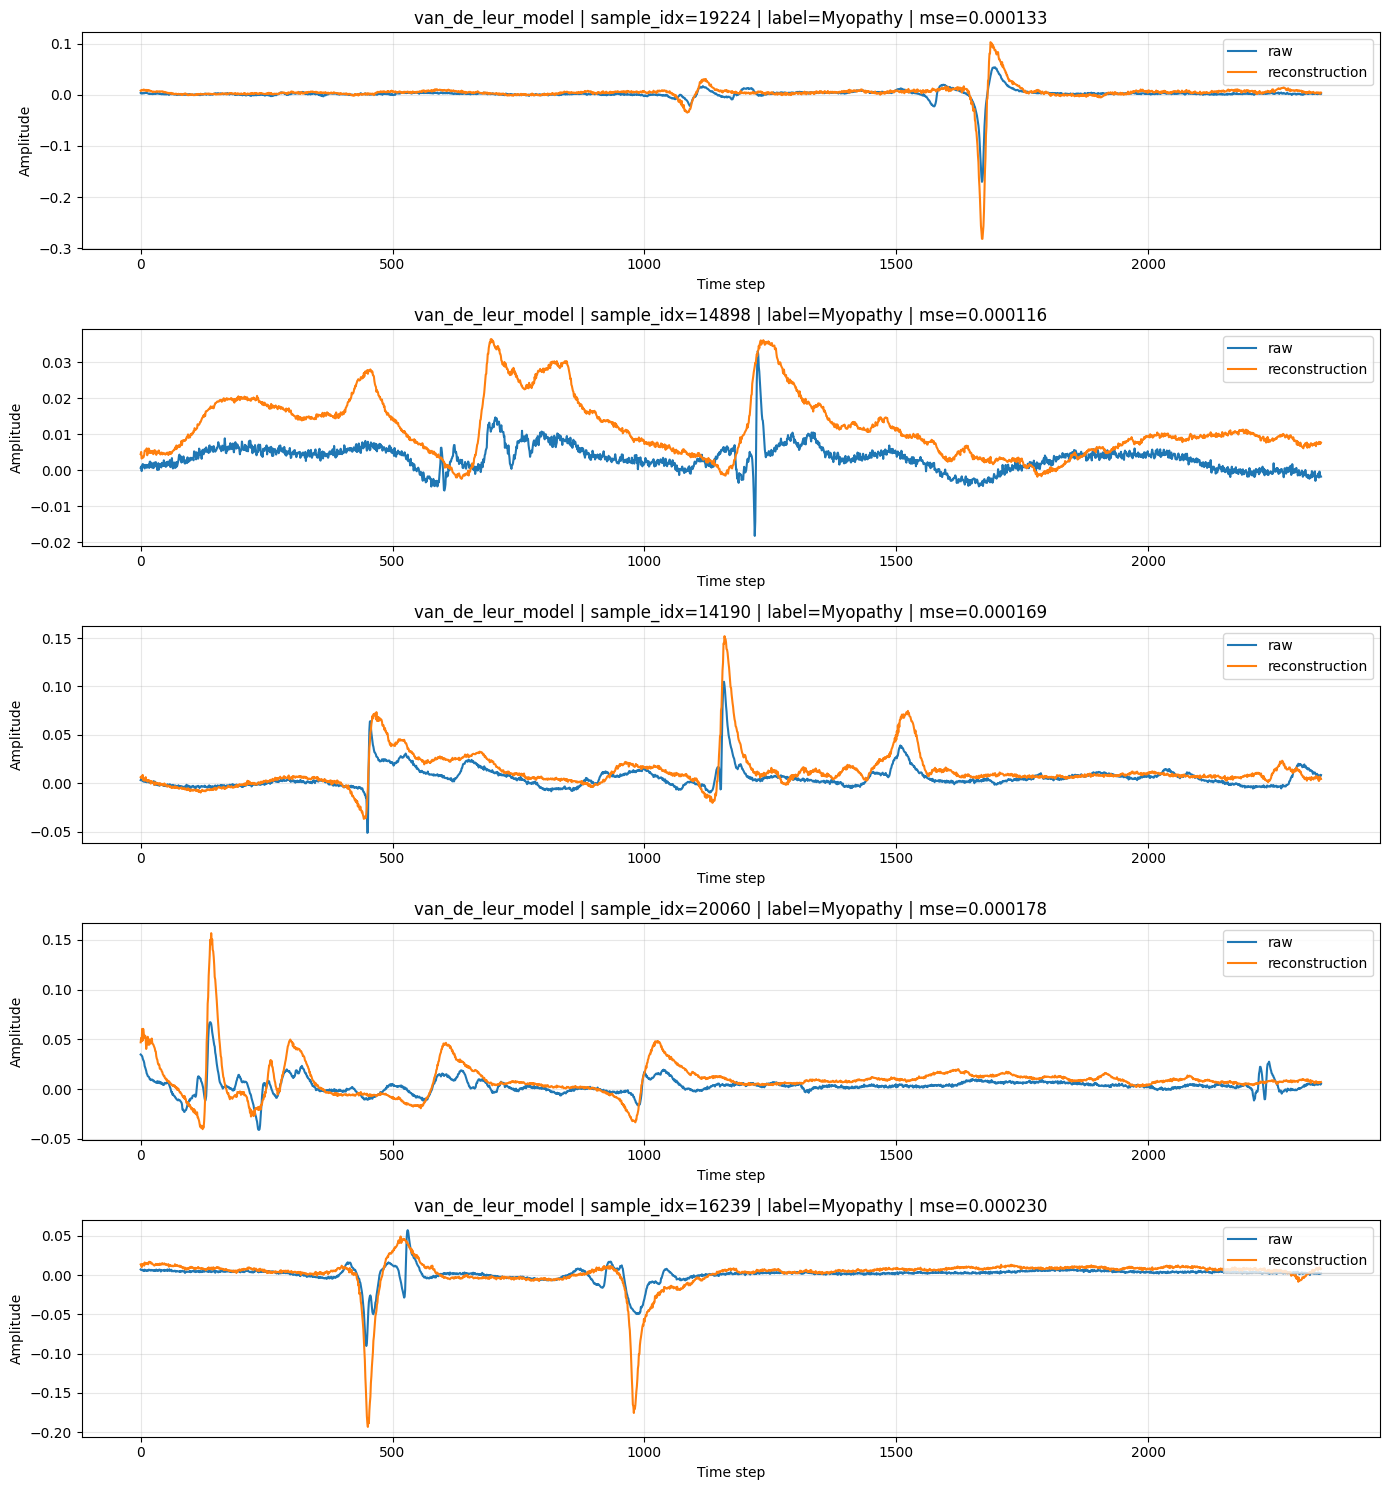

In [40]:
selected_indices = sample_indices_for_label(
    dataset=dataset,
    target_label="Myopathy",  # "ALS", "Normal", "Myopathy"
    n_samples=NUM_RANDOM_SAMPLES,
    seed=RANDOM_SEED,
)

raw_batch, labels = fetch_samples(dataset, selected_indices)

print("Selected indices:", selected_indices)
print("Selected label:", TARGET_LABEL)
print("Raw batch shape:", tuple(raw_batch.shape))

recon_batch = reconstruct_batch(
    model=model,
    batch_x=raw_batch,
    device=DEVICE,
    deterministic=DETERMINISTIC_RECON,
)

print("Recon batch shape:", tuple(recon_batch.shape))

plot_reconstructions(
    raw_batch=raw_batch,
    recon_batch=recon_batch,
    indices=selected_indices,
    labels=labels,
    title_prefix=f"{inferred_model_kind} | ",
)

## Optional: save the current figure

In [ ]:
SAVE_FIG = False
SAVE_PATH = Path("reconstruction_examples.png")

if SAVE_FIG:
    SAVE_PATH = resolve_path(SAVE_PATH, repo_root)
    plt.gcf().savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
    print("Saved:", SAVE_PATH)

: 